# Praktikum Kecerdasan Artifisial Lanjut


---
## Bab 3. Representasi Data


Nama: Erza Hanif Pramudita Hanggara

NIM: 245150200111038

Kelas: TIF-A

## Instalasi Library
Jalankan kode berikut untuk memastikan library telah terinstal di Google Colab.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import sklearn as sk

## Memuat Dataset
### Memuat Dataset Lokal
Unggah file `kontak.csv` yang sudah dibuat tadi ke Google Colab menggunakan kode berikut:

In [35]:
from google.colab import files
kontak = files.upload()

for fn in kontak.keys():
  print(f'Nama file "{fn}" dengan panjang {len(kontak[fn])} bytes')

Saving kontak.csv to kontak (1).csv
Nama file "kontak (1).csv" dengan panjang 103 bytes


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Memuat Dataset dari Internet
Unduh dataset Iris menggunakan wget:

In [9]:
!wget https://dataset-ppm.s3.amazonaws.com/iris_missing.csv

--2026-03-11 08:46:34--  https://dataset-ppm.s3.amazonaws.com/iris_missing.csv
Resolving dataset-ppm.s3.amazonaws.com (dataset-ppm.s3.amazonaws.com)... 3.5.133.240, 3.5.91.38, 52.219.179.236, ...
Connecting to dataset-ppm.s3.amazonaws.com (dataset-ppm.s3.amazonaws.com)|3.5.133.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4593 (4.5K) [text/csv]
Saving to: ‘iris_missing.csv’

iris_missing.csv    100%[===================>]   4.49K  --.-KB/s    in 0s      

2026-03-11 08:46:34 (82.7 MB/s) - ‘iris_missing.csv’ saved [4593/4593]



### Cek File
Cek file yang telah diunduh atau diunggah menggunakan perintah berikut:

In [10]:
!ls

iris_missing.csv  kontak.csv  sample_data


## Membaca Format CSV (pada section ini untuk `kontak.csv`)
### Menggunakan List

In [38]:
import csv

def csv_list(filename):
  data = []

  with open(filename, mode='r') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')

    for row in csv_reader:
      data.append(row)

  data.pop(0)
  return data

In [39]:
list_kontak = csv_list('kontak.csv')
list_kontak

[['1', 'Achmad Ali', '081234'],
 ['2', 'Budi Utomo', '08712333'],
 ['3', 'Toni Saja', '08733311'],
 ['4', 'Dewi Utami', '0851231']]

### Menggunakan Dictionary

In [36]:
import csv

def csv_dist(filename):
  data = []

  with open(filename, mode='r') as csv_file:
    csv_reader = csv.DictReader(csv_file)

    for row in csv_reader:
      data.append(row)

  return data

In [37]:
csv_data = csv_dist("kontak.csv")

print("Hasil dari csv_dict:")
for row in csv_data:
  print(row)

Hasil dari csv_dict:
{'NO': '1', 'NAMA': 'Achmad Ali', 'TELEPON': '081234'}
{'NO': '2', 'NAMA': 'Budi Utomo', 'TELEPON': '08712333'}
{'NO': '3', 'NAMA': 'Toni Saja', 'TELEPON': '08733311'}
{'NO': '4', 'NAMA': 'Dewi Utami', 'TELEPON': '0851231'}


## Membaca CSV menggunakan Pandas (pada section ini untuk dataset `Iris`)

In [40]:
iris_df = pd.read_csv('/content/iris_missing.csv')

In [42]:
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,0.0,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Meringkas Kumpulan Data

In [47]:
print(iris_df.head(6))
print()
print(iris_df.shape)
print()
print(iris_df.describe())
print()
print(iris_df.groupby('Species').size())

   sepal_length  sepal_width  petal_length  petal_width      Species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           0.0          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa

(150, 5)

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.731333     2.988000      3.684667     1.147333
std        1.153352     0.604893      1.826675     0.773790
min        0.000000     0.000000      0.000000     0.000000
25%        5.100000     2.800000      1.500000     0.225000
50%        5.800000     3.000000      4.300000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.

## Visualisasi Kumpulan Data
### Box Plot

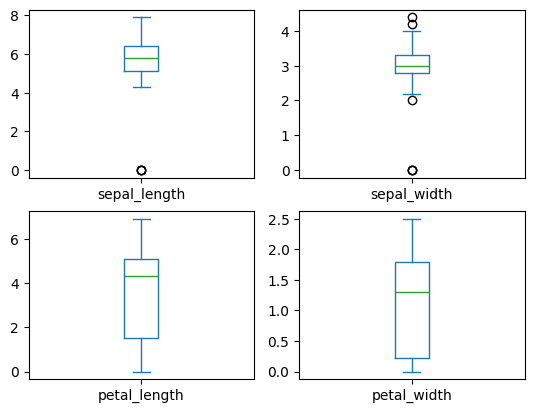

In [48]:
iris_df.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)

plt.show()

### Histogram

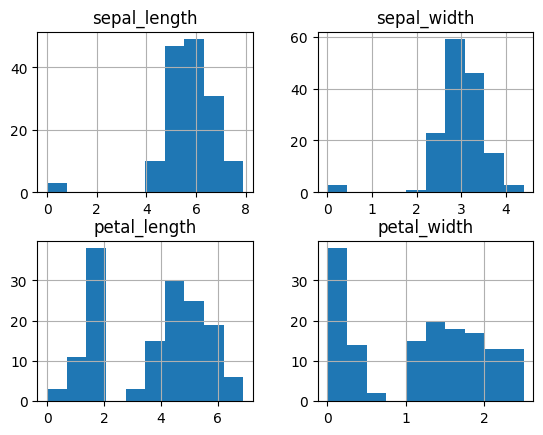

In [49]:
iris_df.hist()

plt.show()

### Scatter Plot Matrix

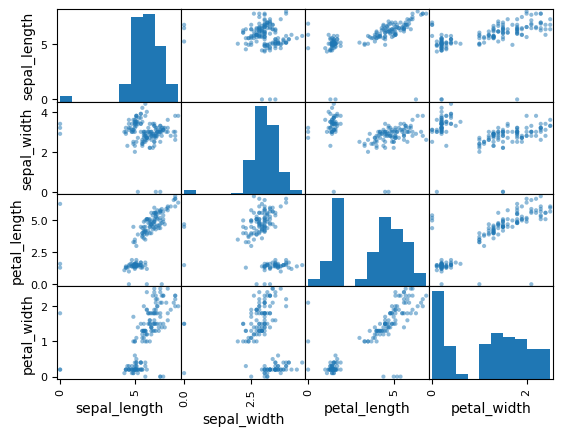

In [51]:
from pandas.plotting import scatter_matrix

scatter_matrix(iris_df)

plt.show()

## **Tugas**

1. Download Glass dataset dari https://archive.ics.uci.edu/dataset/42/glass+identification
Lalu upload file ke menu Files.

In [69]:
glass_data = files.upload()

Saving glass.data to glass.data


**Penjelasan**

Mendownload dataset glass tersebut dan melakukan upload ke google colab. Sebelum melakukan upload, dataset terlebih dahulu saya beri header sesuai nama variabelnya untuk memudahkan proses kedepannya.

2. Masukkan data Glass ke DataFrame menggunakan Pandas.

In [70]:
glass_df = pd.read_csv('/content/glass.data')

**Penjelasan**

Menggunakan pandas untuk membaca dataset sebelumnya kedalam bentuk dataframe dan menyimpannya dalam glass_df.

3. Tampilkan 10 data pertama.

In [71]:
glass_df.head(10)

,ID,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.00,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.00,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.00,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.00,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.00,1
5,6,1.51596,12.79,3.61,1.62,72.97,0.64,8.07,0.0,0.26,1
6,7,1.51743,13.30,3.60,1.14,73.09,0.58,8.17,0.0,0.00,1
7,8,1.51756,13.15,3.61,1.05,73.24,0.57,8.24,0.0,0.00,1
8,9,1.51918,14.04,3.58,1.37,72.08,0.56,8.30,0.0,0.00,1
9,10,1.51755,13.00,3.60,1.36,72.99,0.57,8.40,0.0,0.11,1


**Penjelasan**

Menampikan 10 data teratas dari dataframe dengan fungsi head berparameter 10.

4. Hitung rata-rata nilai per variabel untuk setiap data.

In [80]:
print("Mean RI =",glass_df["RI"].mean())
print("Mean Na =",glass_df["Na"].mean())
print("Mean Mg =",glass_df["Mg"].mean())
print("Mean Al =",glass_df["Al"].mean())
print("Mean Si =",glass_df["Si"].mean())
print("Mean K =",glass_df["K"].mean())
print("Mean Ca =",glass_df["Ca"].mean())
print("Mean Ba =",glass_df["Ba"].mean())
print("Mean Fe =",glass_df["Fe"].mean())

Mean RI = 1.5183654205607477
Mean Na = 13.407850467289718
Mean Mg = 2.684532710280374
Mean Al = 1.444906542056075
Mean Si = 72.65093457943925
Mean K = 0.4970560747663551
Mean Ca = 8.95696261682243
Mean Ba = 0.17504672897196263
Mean Fe = 0.05700934579439253


**Penjelasan**

Melakukan penghitungan mean kepada semua atribut/variabel dari dataset dengan menggunakan fungsi mean yang tertuju pada nama masing masing atribut (karena inilah saya beri header sebelumnya).

5. Hitung rata-rata nilai per variabel untuk setiap data dikelompokkan berdasarkan Type.

In [84]:
print(glass_df.drop("ID", axis=1).groupby('Type').mean())

            RI         Na        Mg        Al         Si         K         Ca  \
Type                                                                            
1     1.518718  13.242286  3.552429  1.163857  72.619143  0.447429   8.797286   
2     1.518619  13.111711  3.002105  1.408158  72.598026  0.521053   9.073684   
3     1.517964  13.437059  3.543529  1.201176  72.404706  0.406471   8.782941   
5     1.518928  12.827692  0.773846  2.033846  72.366154  1.470000  10.123846   
6     1.517456  14.646667  1.305556  1.366667  73.206667  0.000000   9.356667   
7     1.517116  14.442069  0.538276  2.122759  72.965862  0.325172   8.491379   

            Ba        Fe  
Type                      
1     0.012714  0.057000  
2     0.050263  0.079737  
3     0.008824  0.057059  
5     0.187692  0.060769  
6     0.000000  0.000000  
7     1.040000  0.013448  


**Penjelasan**

Melakukan drop terlebih dahulu kepada kolom ID (karena tidak relevan untuk penghitungan mean) lalu enggunakan fungsi groupby pada dataset berdasarkan typenya untuk kemudian memanggil fungsi mean, yang menghasilkan mean dari semua atribut yang dipisahkan/dikelompokkan berdasarkan typenya.

6. Buatlah plot bertipe 'line' untuk masing-masing variabelnya menggunakan Pandas Plot.

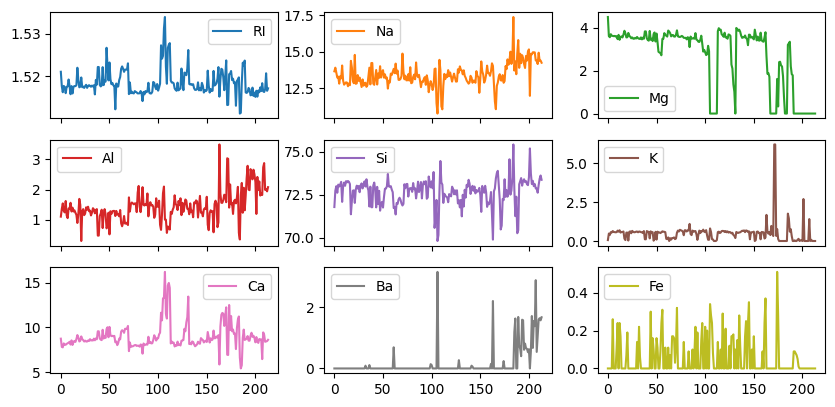

In [109]:
glass_df.drop(["ID", "Type"], axis=1).plot(kind='line', subplots=True, layout=(5,3), figsize=(10,8))

plt.show()

**Penjelasan**

Melakukan drop terlebih dahulu pada kolom ID dan Type yang tidak relevan, kemudian memanggil fungsi plot untuk melakukan plotting berbentuk line plot dengan subplots true agar masing masing variabel memiliki plot masing masing.

## Kesimpulan

Python memiliki banyak jenis library yang dapat digunakan untuk representasi data yang memiliki kegunaan yang berbeda beda. Mulai dari numpy untuk perhitungan numerik, pandas untuk manipulasi data, matplotlib untuk plotting, scipy untuk perhitungan kompleks, dan scikit-learn untuk library machine learning.
